# Proprioceptive sensing — finger η identification

Fits η = diag(η_MCP, η_PIP) from (q, K, F_measured) triplets recorded by `finger_eta.py`.
Saves fitted transmission efficiencies to `ModelIDFinger/finger_params.py` and also
propagates them to `ModelIDHand/hand_params.py` (long-finger MCP/PIP and thumb MCP/IP).

## Load data

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys, re
from glob import glob
from tqdm import tqdm

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'   # export exactly the displayed (PNG) figure
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

from StiffnessModelFinger.stiffness2fingerspace import tip_stiffness_FingerSpace
from KinematicsFinger.FK_Finger import motor_to_joint, joint_to_motor
from UR5_codes.UR5_config import FINGER_TARGET

OUTPUT_DIR = os.path.join("outputs", "finger_eta")

# Load all runs, tagging each row with its run index
csv_files = sorted(glob(os.path.join(OUTPUT_DIR, "finger_eta_run_*.csv")))
assert csv_files, f"No CSV files found in {OUTPUT_DIR}"
dfs = []
for run_id, f in enumerate(csv_files):
    d = pd.read_csv(f)
    d["Run_ID"] = run_id
    dfs.append(d)
df = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(csv_files)} run(s), {len(df)} rows, "
      f"{df.groupby(['Run_ID','Sample_Num']).ngroups} samples total")

# Reference: FINGER_TARGET is joint-space angles; convert to motor angles
q_ref_rad = joint_to_motor(FINGER_TARGET)
print(f"FINGER_TARGET (joint): {np.rad2deg(FINGER_TARGET)} (deg)")
print(f"Reference motor angles: {np.rad2deg(q_ref_rad)} (deg)")

Loaded 1 run(s), 898598 rows, 200 samples total
FINGER_TARGET (joint): [30. 30. 30.] (deg)
Reference motor angles: [67.26457399 48.78      ] (deg)


## Fit transmission efficiency via least squares

In [10]:
# Build Phi and target f on per-sample averages
## Each sample = one (Run_ID, Sample_Num), averaged over its RECORD_INTERVAL rows
## Model: F_n = Phi @ [eta_MCP, eta_PIP]

n_vec = np.array([0.0, 0.0, 1.0])
sm = tip_stiffness_FingerSpace(n=n_vec, eta=np.array([1.0, 1.0]))

# Aggregate one representative row per sample (mean over time window)
sample_df = (
    df.groupby(['Run_ID', 'Sample_Num'], as_index=False)
      .agg({
          'Force_Total_N': 'mean',
          'Force_Normal_N': 'mean',
          'Force_Shear_N': 'mean',
          'Motor1_pos_deg': 'mean',
          'Motor2_pos_deg': 'mean',
          'Stiffness_MCP': 'mean',
          'Stiffness_PIP': 'mean',
          'Stiffness_DIP': 'mean',
      })
)

N = len(sample_df)
Phi = np.zeros((N, 2))
f = sample_df['Force_Total_N'].to_numpy().copy()

for ii, row in tqdm(enumerate(sample_df.itertuples()), total=N, desc='Building Phi (sample means)'):
    q_rad = np.radians([row.Motor1_pos_deg, row.Motor2_pos_deg])
    K = np.diag([row.Stiffness_MCP, row.Stiffness_PIP, row.Stiffness_DIP])

    J_theta = np.array(sm.J_theta(q_rad[0], q_rad[1]))
    J_tip_P = sm.P @ np.array(sm.J_tip(q_rad[0], q_rad[1],
                                     sm.rtip[0], sm.rtip[1], sm.rtip[2]))
    J_pinv = np.linalg.pinv(J_tip_P)

    delta_theta = motor_to_joint(q_ref_rad) - motor_to_joint(q_rad)
    tau = J_theta.T @ K @ delta_theta
    a = J_pinv @ n_vec
    Phi[ii, 0] = a[0] * tau[0]
    Phi[ii, 1] = a[1] * tau[1]

# Fit on all samples
eta_vec, _, _, _ = np.linalg.lstsq(Phi, f, rcond=None)
ETA_MCP, ETA_PIP = eta_vec

f_pred_all = Phi @ eta_vec

def r2(y, yp):
    return 1 - np.sum((y - yp)**2) / np.sum((y - np.mean(y))**2)

rmse = lambda y, yp: np.sqrt(np.mean((y - yp)**2))

print(f'eta_MCP = {ETA_MCP:.4f}  eta_PIP = {ETA_PIP:.4f}')
print(f'R2={r2(f, f_pred_all):.4f}  RMSE={rmse(f, f_pred_all)*1000:.2f} mN')

Building Phi (sample means): 100%|██████████| 200/200 [00:00<00:00, 40335.66it/s]

eta_MCP = 0.8373  eta_PIP = 0.3594
R2=0.8360  RMSE=100.36 mN


## Visualize fit quality

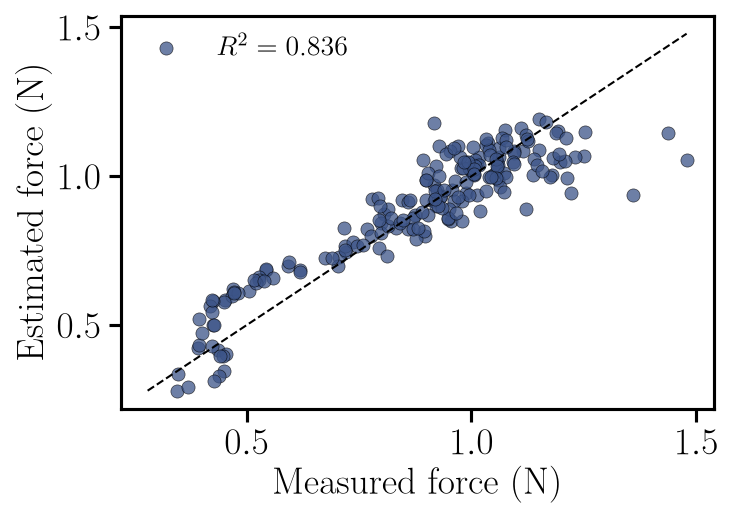

In [16]:
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN     = 8.5 * 0.6    # figure width (inches)
ASPECT   = 6 / 9         # height / width  ->  set to change proportions
H_IN     = W_IN * ASPECT
DOT_SIZE = 40             # scatter marker size (points^2) — change freely

# Dot color — pick one:
#   '#3C5488'   navy    (house palette COLORS[3]; default below)
#   '#00A087'   teal    (house palette COLORS[2])
#   '#7E6148'   brown   (house palette COLORS[8])
#   '#005AB5'   IBM colorblind-safe blue
#   'steelblue' matplotlib named color
DOT_COLOR = '#3C5488'

os.makedirs(OUTPUT_DIR, exist_ok=True)
SHOW_R2 = True  # set to False to hide R² from legend

fig, ax = plt.subplots(figsize=(W_IN, H_IN))
lbl = rf"$R^2 = {r2(f, f_pred_all):.3f}$" if SHOW_R2 else None
ax.scatter(f, f_pred_all, s=DOT_SIZE, alpha=0.75, color=DOT_COLOR,
           edgecolors='black', linewidths=0.3, label=lbl)
lims = [min(f.min(), f_pred_all.min()), max(f.max(), f_pred_all.max())]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("Measured force (N)")
ax.set_ylabel("Estimated force (N)")
if SHOW_R2:
    ax.legend()
fig.savefig(os.path.join(OUTPUT_DIR, "eta_scatter.pdf"))
plt.show()

## Save fitted parameters

In [12]:
# Finger params ---------------------------------------------------------------
params_path = os.path.join("../..", "ModelIDFinger", "finger_params.py")
with open(params_path, "r") as fh:
    src = fh.read()

src = re.sub(r"ETA_MCP\s*=\s*-?[0-9.]+", f"ETA_MCP = {ETA_MCP:.4f}", src)
src = re.sub(r"ETA_PIP\s*=\s*-?[0-9.]+", f"ETA_PIP = {ETA_PIP:.4f}", src)

with open(params_path, "w") as fh:
    fh.write(src)

print(f"Finger: ETA_MCP={ETA_MCP:.4f}, ETA_PIP={ETA_PIP:.4f} -> {params_path}")

# Hand params -----------------------------------------------------------------
# Propagate finger η to all 13 hand motor slots. The 4 long fingers (index,
# middle, ring, pinky) share the same transmission hardware as the test finger
# (same r_motor, r_pulley, c_param), and the thumb MCP/IP use a mechanistically
# analogous cable-driven c-pulley transmission — these 10 slots inherit the
# fitted values. The remaining 3 (thumb CMC1/CMC2, spread) use
# different mechanisms (gear-driven, large direct-drive pulleys, differential
# coupling) and are written explicitly as 1.0.

hand_params_path = os.path.join("../..", "ModelIDHand", "hand_params.py")
with open(hand_params_path, "r") as fh:
    hsrc = fh.read()

hand_eta_assignments = {
    # Long fingers — identical transmission hardware to the test finger
    "ETA_INDEX_MCP":  ETA_MCP,
    "ETA_INDEX_PIP":  ETA_PIP,
    "ETA_MIDDLE_MCP": ETA_MCP,
    "ETA_MIDDLE_PIP": ETA_PIP,
    "ETA_RING_MCP":   ETA_MCP,
    "ETA_RING_PIP":   ETA_PIP,
    "ETA_PINKY_MCP":  ETA_MCP,
    "ETA_PINKY_PIP":  ETA_PIP,
    # Thumb MCP/IP — cable-driven c-pulley (analogous to finger PIP mechanism)
    "ETA_THUMB_MCP":  ETA_MCP,
    "ETA_THUMB_IP":   ETA_PIP,
    # Different mechanisms — left at unity (no identified value)
    "ETA_THUMB_CMC1": 1.0,
    "ETA_THUMB_CMC2": 1.0,
    "ETA_SPREAD":     1.0,
}

for name, value in hand_eta_assignments.items():
    hsrc, n = re.subn(rf"^{name}\s*=\s*-?[0-9.]+",
                      f"{name} = {value:.4f}",
                      hsrc, count=1, flags=re.MULTILINE)
    assert n == 1, f"Failed to update {name}"

with open(hand_params_path, "w") as fh:
    fh.write(hsrc)

print(f"Hand:   wrote all 13 ETA_* values to {hand_params_path}")


Finger: ETA_MCP=0.8373, ETA_PIP=0.3594 -> ../..\ModelIDFinger\finger_params.py
Hand:   wrote all 13 ETA_* values to ../..\ModelIDHand\hand_params.py
